Dataset Overview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

orders     = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
customers  = pd.read_csv("customers.csv")
drivers    = pd.read_csv("drivers.csv")
complaints = pd.read_csv("complaints.csv")
incidents  = pd.read_csv("incidents.csv")
vehicles   = pd.read_csv("vehicles.csv")
hubs       = pd.read_csv("hubs.csv")
app_events = pd.read_csv("app_events.csv")

print("=== Dataset Overview ===")
for name, df in [("orders",orders),
                  ("deliveries",deliveries),
                  ("customers",customers),
                  ("drivers",drivers),
                  ("complaints",complaints),
                  ("incidents",incidents),
                  ("vehicles",vehicles),
                  ("hubs",hubs),
                  ("app_events",app_events)]:
    print(f"{name:15s}: {df.shape[0]:>5} rows"
          f"  {df.shape[1]:>3} columns")

=== Dataset Overview ===
orders         :  1250 rows   11 columns
deliveries     :   950 rows   13 columns
customers      :   650 rows    9 columns
drivers        :   170 rows    8 columns
complaints     :   320 rows   10 columns
incidents      :   280 rows    7 columns
vehicles       :   120 rows    8 columns
hubs           :     8 rows    5 columns
app_events     :   640 rows   10 columns


Data Cleaning

In [ ]:
print("=== Missing Values Per Dataset ===")
for name, df in [("orders",orders),
                  ("deliveries",deliveries),
                  ("customers",customers),
                  ("complaints",complaints),
                  ("drivers",drivers),
                  ("vehicles",vehicles)]:
    missing = df.isnull().sum().sum()
    print(f"{name:15s}: {missing} missing values")

print("\n=== Zone Names BEFORE Cleaning ===")
print(sorted(orders['pickup_zone'].unique()))

orders['pickup_zone'] = (
    orders['pickup_zone'].str.strip().str.title())
orders['dropoff_zone'] = (
    orders['dropoff_zone'].str.strip().str.title())
customers['home_zone'] = (
    customers['home_zone'].str.strip().str.title())
app_events['zone_context'] = (
    app_events['zone_context'].str.strip().str.title())
deliveries['delivery_status'] = (
    deliveries['delivery_status'].str.strip())

print("\n=== Zone Names AFTER Cleaning ===")
print(sorted(orders['pickup_zone'].unique()))

print("\n=== Delivery Status Values ===")
print(deliveries['delivery_status'].value_counts())

=== Missing Values Per Dataset ===
orders         : 25 missing values
deliveries     : 33 missing values
customers      : 33 missing values
complaints     : 16 missing values
drivers        : 7 missing values
vehicles       : 4 missing values

=== Zone Names BEFORE Cleaning ===
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

=== Zone Names AFTER Cleaning ===
['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']

=== Delivery Status Values ===
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


Feature Engineering

In [ ]:
deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at'], errors='coerce')

deliveries['delivery_duration_hours'] = (
    deliveries['delivery_completed_at'] -
    deliveries['dispatch_time']
).dt.total_seconds() / 3600

deliveries['is_failed'] = (
    deliveries['delivery_status'] == 'Failed'
).astype(int)

deliveries['dispatch_hour'] = (
    deliveries['dispatch_time'].dt.hour)

deliveries['dispatch_day'] = (
    deliveries['dispatch_time'].dt.day_name())

print("=== New Features Created ===")
print(deliveries[['delivery_id',
                   'delivery_duration_hours',
                   'is_failed',
                   'dispatch_hour',
                   'dispatch_day']].head(10))

print(f"\nNegative durations (data errors): "
      f"{(deliveries['delivery_duration_hours']<0).sum()}")
print(f"Mean delivery duration: "
      f"{deliveries['delivery_duration_hours'].mean():.2f}"
      f" hours")

=== New Features Created ===
  delivery_id  delivery_duration_hours  is_failed  dispatch_hour dispatch_day
0     DL00001                22.149973          1             10      Tuesday
1     DL00002                -1.100000          0             18     Saturday
2     DL00003                 1.108991          0             20       Monday
3     DL00004                23.985584          0             23       Friday
4     DL00005                 4.042814          0             11       Sunday
5     DL00006                28.531218          0             12    Wednesday
6     DL00007                33.969742          0             13      Tuesday
7     DL00008                 1.805981          0             21     Thursday
8     DL00009                 3.764631          0             21       Friday
9     DL00010                 6.108098          1             19       Monday

Negative durations (data errors): 64
Mean delivery duration: 9.55 hours


Hub Performance Analysis

=== Hub Performance Summary ===
         hub_name       zone  total  failed  failure_rate  avg_rating
0  North Exchange      North    136      17         12.50    3.840593
1      South Link      South    106      10          9.43    3.950952
2       East Dock       East    119      11          9.24    3.895862
3       West Gate       West    127      16         12.60    3.915476
4    Central Core    Central    115      23         20.00    3.669558
5     Airport Hub    Airport    104      15         14.42    3.882136
6   Riverside Hub  Riverside    115      14         12.17    3.881858
7   Midtown Relay    Central    128      26         20.31    3.884560


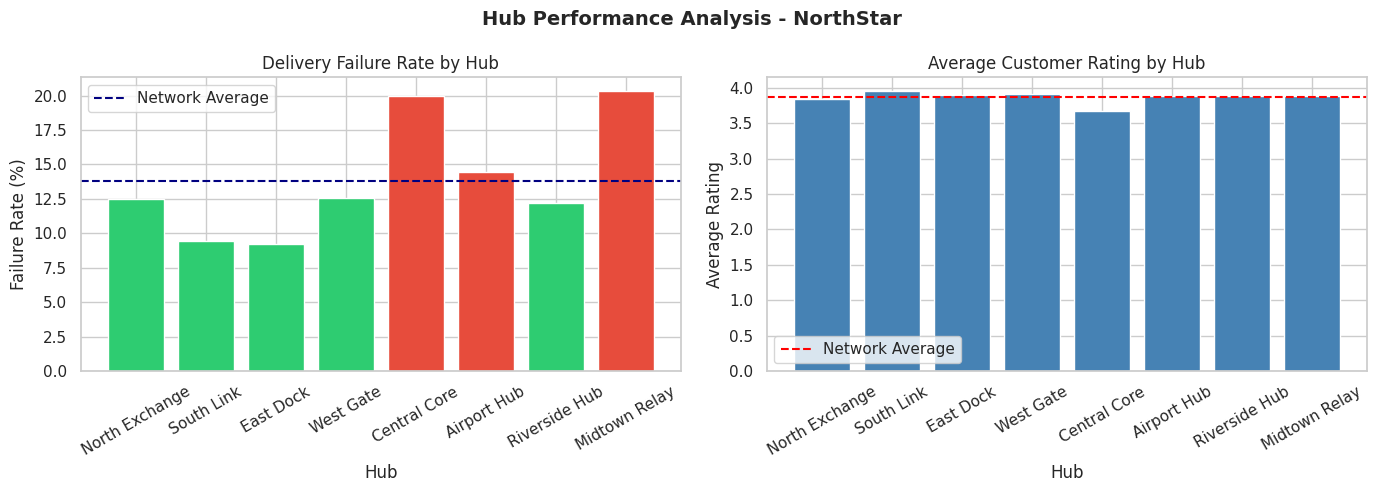

In [ ]:
hub_analysis = deliveries.merge(
    hubs[['hub_id','hub_name','zone']], on='hub_id')

hub_stats = hub_analysis.groupby(
    ['hub_id','hub_name','zone']).agg(
    total=('delivery_id','count'),
    failed=('is_failed','sum'),
    avg_rating=('customer_rating_post_delivery','mean'),
    avg_cost=('fuel_or_charge_cost','mean')
).reset_index()

hub_stats['failure_rate'] = (
    hub_stats['failed'] /
    hub_stats['total'] * 100).round(2)

print("=== Hub Performance Summary ===")
print(hub_stats[['hub_name','zone','total',
                  'failed','failure_rate',
                  'avg_rating']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].bar(
    hub_stats['hub_name'],
    hub_stats['failure_rate'],
    color=['#e74c3c'
           if x > hub_stats['failure_rate'].mean()
           else '#2ecc71'
           for x in hub_stats['failure_rate']])
axes[0].axhline(
    hub_stats['failure_rate'].mean(),
    color='navy', linestyle='--',
    label='Network Average')
axes[0].set_title('Delivery Failure Rate by Hub')
axes[0].set_xlabel('Hub')
axes[0].set_ylabel('Failure Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

axes[1].bar(
    hub_stats['hub_name'],
    hub_stats['avg_rating'],
    color='steelblue')
axes[1].axhline(
    hub_stats['avg_rating'].mean(),
    color='red', linestyle='--',
    label='Network Average')
axes[1].set_title('Average Customer Rating by Hub')
axes[1].set_xlabel('Hub')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle(
    'Hub Performance Analysis - NorthStar',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Reload all datasets
orders     = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
customers  = pd.read_csv("customers.csv")
drivers    = pd.read_csv("drivers.csv")
complaints = pd.read_csv("complaints.csv")
incidents  = pd.read_csv("incidents.csv")
vehicles   = pd.read_csv("vehicles.csv")
hubs       = pd.read_csv("hubs.csv")
app_events = pd.read_csv("app_events.csv")

# Redo cleaning
orders['pickup_zone'] = (
    orders['pickup_zone'].str.strip().str.title())
orders['dropoff_zone'] = (
    orders['dropoff_zone'].str.strip().str.title())
customers['home_zone'] = (
    customers['home_zone'].str.strip().str.title())
app_events['zone_context'] = (
    app_events['zone_context'].str.strip().str.title())
deliveries['delivery_status'] = (
    deliveries['delivery_status'].str.strip())

# Redo feature engineering
deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at'], errors='coerce')
deliveries['delivery_duration_hours'] = (
    deliveries['delivery_completed_at'] -
    deliveries['dispatch_time']
).dt.total_seconds() / 3600
deliveries['is_failed'] = (
    deliveries['delivery_status'] == 'Failed'
).astype(int)

print("All data reloaded successfully!")
print(f"Orders: {len(orders)}")
print(f"Deliveries: {len(deliveries)}")
print(f"Vehicles: {len(vehicles)}")
print(f"Incidents: {len(incidents)}")

All data reloaded successfully!
Orders: 1250
Deliveries: 950
Vehicles: 120
Incidents: 280


Vehicle and Battery Health Analysis

Vehicles with battery below 60%: 13
    vehicle_id vehicle_type assigned_zone  battery_health_pct maintenance_status
4         V005     CargoVan          West                58.6             Active
9         V010     CargoVan         NORTH                50.7           InRepair
11        V012       Hybrid         SOUTH                56.2             Active
24        V025       Diesel       AIRPORT                42.0             Active
36        V037     CargoVan         South                56.6           InRepair
48        V049       Diesel          East                55.9             Active
66        V067       Hybrid           Ctr                57.3             Active
83        V084     CargoVan     Riverside                47.6           InRepair
86        V087       Hybrid       AIRPORT                49.7             Active
90        V091       Hybrid          EAST                58.5             Active
107       V108       Diesel       AIRPORT                54.6           I

/tmp/ipykernel_12470/1290852248.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=veh_inc,


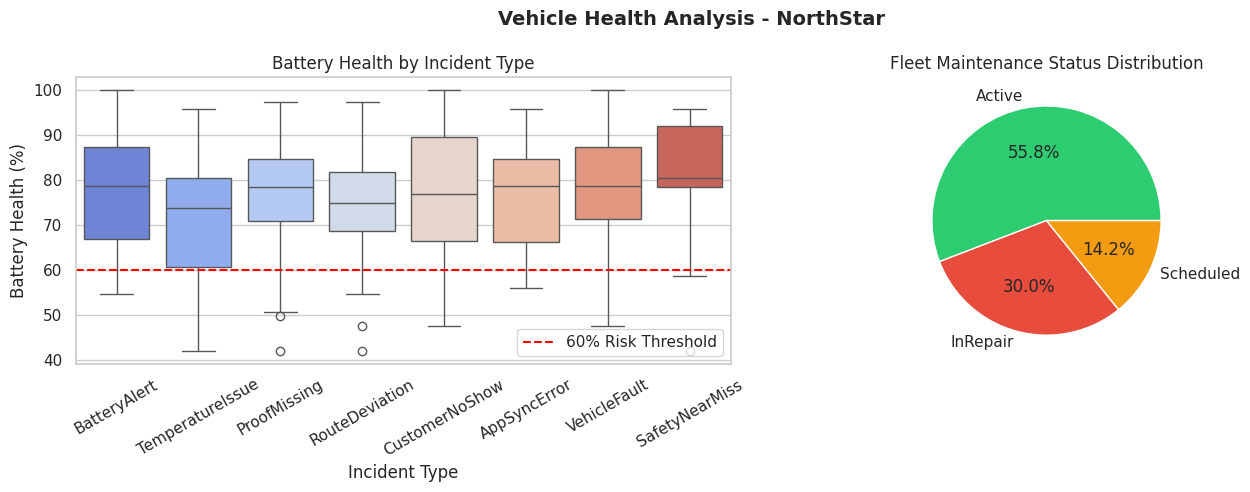

In [ ]:
vehicles['battery_health_pct'] = pd.to_numeric(
    vehicles['battery_health_pct'], errors='coerce')

veh_inc = incidents.merge(
    deliveries[['delivery_id','vehicle_id']],
    on='delivery_id')
veh_inc = veh_inc.merge(
    vehicles[['vehicle_id','battery_health_pct',
               'maintenance_status',
               'vehicle_type','assigned_zone']],
    on='vehicle_id')

low_battery = vehicles[
    vehicles['battery_health_pct'] < 60].copy()
print(f"Vehicles with battery below 60%: "
      f"{len(low_battery)}")
print(low_battery[['vehicle_id','vehicle_type',
                    'assigned_zone',
                    'battery_health_pct',
                    'maintenance_status']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=veh_inc,
            x='incident_type',
            y='battery_health_pct',
            palette='coolwarm',
            ax=axes[0])
axes[0].axhline(60, color='red',
                linestyle='--',
                label='60% Risk Threshold')
axes[0].set_title('Battery Health by Incident Type')
axes[0].set_xlabel('Incident Type')
axes[0].set_ylabel('Battery Health (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

maint = vehicles['maintenance_status'].value_counts()
axes[1].pie(maint.values,
            labels=maint.index,
            autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c',
                    '#f39c12','#3498db'])
axes[1].set_title('Fleet Maintenance Status Distribution')

plt.suptitle(
    'Vehicle Health Analysis - NorthStar',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Customer Complaints Analysis

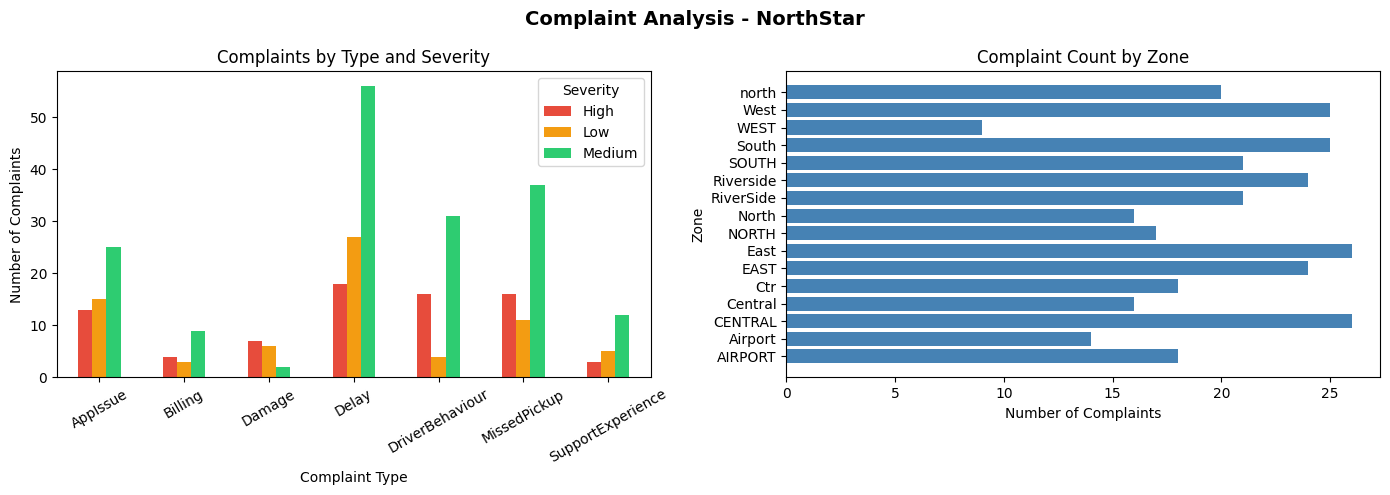


=== Top Complaint Types ===
complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64

=== Average Compensation by Severity ===
severity
High      38.85
Low        9.06
Medium    17.37
Name: compensation_amount, dtype: float64


In [ ]:
comp_counts = complaints.groupby(
    ['complaint_type','severity']
).size().reset_index(name='count')

comp_zone = complaints.merge(
    orders[['order_id','pickup_zone']],
    on='order_id', how='left')
zone_comp = comp_zone.groupby(
    'pickup_zone').size().reset_index(
    name='complaint_count')

fig, axes = plt.subplots(1, 2, figsize=(14,5))

comp_pivot = comp_counts.pivot(
    index='complaint_type',
    columns='severity',
    values='count').fillna(0)
comp_pivot.plot(kind='bar', ax=axes[0],
                color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Complaints by Type and Severity')
axes[0].set_xlabel('Complaint Type')
axes[0].set_ylabel('Number of Complaints')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Severity')

axes[1].barh(zone_comp['pickup_zone'],
             zone_comp['complaint_count'],
             color='steelblue')
axes[1].set_title('Complaint Count by Zone')
axes[1].set_xlabel('Number of Complaints')
axes[1].set_ylabel('Zone')

plt.suptitle('Complaint Analysis - NorthStar',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Top Complaint Types ===")
print(complaints['complaint_type'].value_counts())
print("\n=== Average Compensation by Severity ===")
print(complaints.groupby('severity')[
    'compensation_amount'].mean().round(2))

NumPy Statistical Analysis

=== NumPy Statistical Analysis ===
Count:           867
Mean:            10.32 hrs
Median:          7.91 hrs
Std Deviation:   8.46 hrs
Variance:        71.54
Min:             0.02 hrs
Max:             43.46 hrs
25th Percentile: 3.50 hrs
75th Percentile: 15.53 hrs
95th Percentile: 24.83 hrs

Outlier deliveries above 95th percentile: 44
Percentage of total deliveries: 4.6%


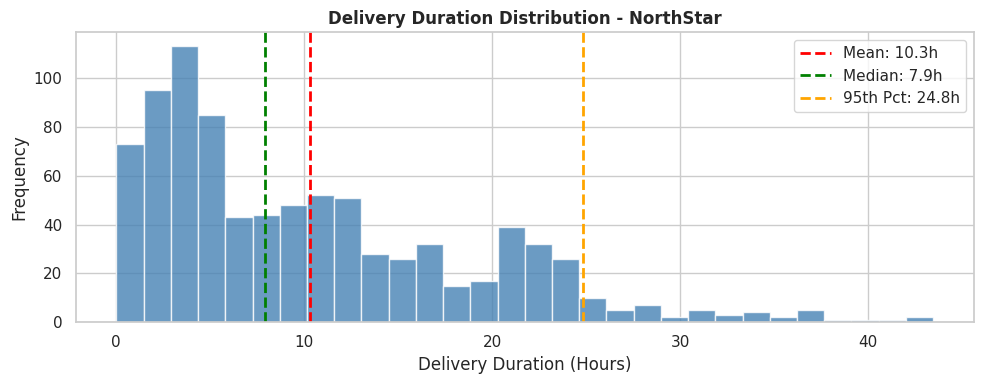

In [ ]:
durations = deliveries[
    'delivery_duration_hours'].dropna()
durations = durations[durations >= 0]

print("=== NumPy Statistical Analysis ===")
print(f"Count:           {len(durations)}")
print(f"Mean:            {np.mean(durations):.2f} hrs")
print(f"Median:          {np.median(durations):.2f} hrs")
print(f"Std Deviation:   {np.std(durations):.2f} hrs")
print(f"Variance:        {np.var(durations):.2f}")
print(f"Min:             {np.min(durations):.2f} hrs")
print(f"Max:             {np.max(durations):.2f} hrs")
print(f"25th Percentile: "
      f"{np.percentile(durations,25):.2f} hrs")
print(f"75th Percentile: "
      f"{np.percentile(durations,75):.2f} hrs")
print(f"95th Percentile: "
      f"{np.percentile(durations,95):.2f} hrs")

threshold = np.percentile(durations, 95)
outliers = deliveries[
    deliveries['delivery_duration_hours'] > threshold]
print(f"\nOutlier deliveries above 95th percentile:"
      f" {len(outliers)}")
print(f"Percentage of total deliveries: "
      f"{len(outliers)/len(deliveries)*100:.1f}%")

plt.figure(figsize=(10,4))
plt.hist(durations, bins=30,
         color='steelblue',
         edgecolor='white', alpha=0.8)
plt.axvline(np.mean(durations),
            color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(durations):.1f}h')
plt.axvline(np.median(durations),
            color='green', linestyle='--', linewidth=2,
            label=f'Median: {np.median(durations):.1f}h')
plt.axvline(threshold,
            color='orange', linestyle='--', linewidth=2,
            label=f'95th Pct: {threshold:.1f}h')
plt.title(
    'Delivery Duration Distribution - NorthStar',
    fontweight='bold')
plt.xlabel('Delivery Duration (Hours)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

Delivery Duration Analysis by Service Type

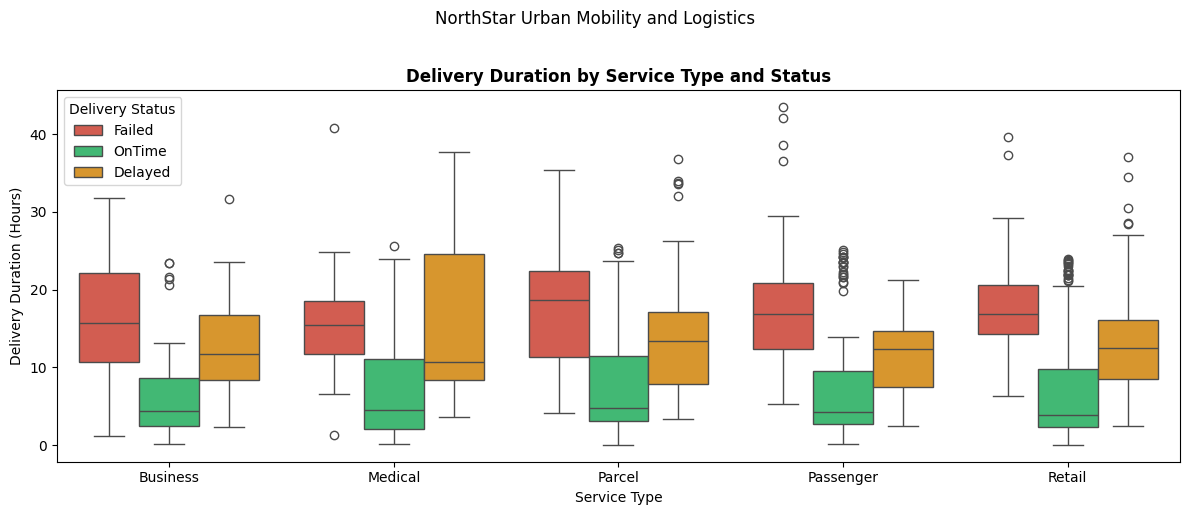

=== Average Duration by Service Type ===
service_type
Business     10.05
Medical      11.01
Parcel       10.63
Passenger     9.98
Retail       10.22
Name: delivery_duration_hours, dtype: float64

=== Average Duration by Status ===
delivery_status
Delayed    13.51
Failed     17.78
OnTime      7.36
Name: delivery_duration_hours, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")

# Redo cleaning for orders, which is a dependency for merging
orders['pickup_zone'] = (orders['pickup_zone'].str.strip().str.title())
orders['dropoff_zone'] = (orders['dropoff_zone'].str.strip().str.title())

# Make sure delivery_duration_hours exists
deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at'], errors='coerce')
deliveries['delivery_duration_hours'] = (
    deliveries['delivery_completed_at'] -
    deliveries['dispatch_time']
).dt.total_seconds() / 3600

# Merge with orders to get service type
duration_analysis = deliveries[
    deliveries['delivery_duration_hours'] >= 0].merge(
    orders[['order_id','service_type']], on='order_id')

plt.figure(figsize=(12,5))
sns.boxplot(data=duration_analysis,
            x='service_type',
            y='delivery_duration_hours',
            hue='delivery_status',
            palette={'Failed':'#e74c3c',
                     'OnTime':'#2ecc71',
                     'Delayed':'#f39c12'}) # Corrected 'Late' to 'Delayed'
plt.title('Delivery Duration by Service Type and Status',
          fontweight='bold')
plt.suptitle('NorthStar Urban Mobility and Logistics',
             y=1.02)
plt.xlabel('Service Type')
plt.ylabel('Delivery Duration (Hours)')
plt.legend(title='Delivery Status')
plt.tight_layout()
plt.show()

print("=== Average Duration by Service Type ===")
print(duration_analysis.groupby(
    'service_type')['delivery_duration_hours'].mean().round(2))
print("\n=== Average Duration by Status ===")
print(duration_analysis.groupby(
    'delivery_status')['delivery_duration_hours'].mean().round(2))